In [ ]:
# from ultralytics import RTDETR

# model = RTDETR("rtdetr-l.pt")
# model.info()

# results = model.train(data='./Scananagrams.yolov8', epochs = 50, imgsz=640)

## Read in Image, Identify Tiles


image 1/1 c:\IzzysWorkshop\PeelBack\unAnnotatedImages\WoodBG.jpg: 640x640 18 Tiles, 525.5ms
Speed: 2.9ms preprocess, 525.5ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
average Tile Length: 316.6111111111111
Total tiles scanned: 18


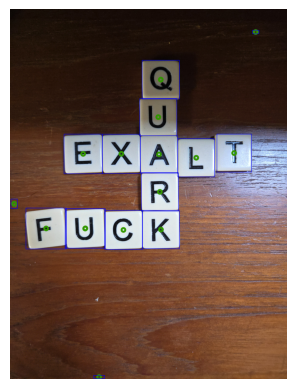

In [24]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import RTDETR
import numpy as np


imagePath = 'unAnnotatedImages/WoodBG.jpg'

image = cv2.imread(imagePath, cv2.IMREAD_COLOR_RGB)

drawOn = image.copy()

myModel = RTDETR('runs/detect/train/weights/best.pt')
result = myModel.predict(imagePath)

boxes = result[0].boxes.xyxy.cpu().numpy()
boxes = boxes.astype(np.int64)
centers = []

for x1,y1,x2,y2 in boxes:
    # x1,y1,x2,y2 = map(int,box)
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    centers.append([xAvg,yAvg])

    cv2.circle(drawOn, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn, (x1,y1),(x2,y2), (0,0,250),3)

centers = np.asarray(centers)

def findNewAvgTileLen(boxes):
    z = np.average(boxes[:,2]-boxes[:,0])
    y = np.average(boxes[:,3]-boxes[:,1])
    newAvg = (y+z)/2
    return newAvg

avgTileLen = findNewAvgTileLen(boxes)

print(f'average Tile Length: {avgTileLen}')
print(f'Total tiles scanned: {len(boxes)}')
plt.imshow(drawOn)
plt.axis('off')
plt.show()

## Filter for duplicates and false positives

### Filter By Aspect Ratio 

In [ ]:
heights = boxes[:,3] - boxes[:,1]
widths = boxes[:,2] - boxes[:,0]
aspectRatios = widths/heights

ratioMOE = .1
maxRatio = avgTileLen * (1+ratioMOE)
minRatio = avgTileLen * (1-ratioMOE)

conditions = (.9<aspectRatios) & (aspectRatios<1.1) 
boxes = boxes[conditions]

IndexError: index 13 is out of bounds for axis 0 with size 13

### Filter by Length and Width

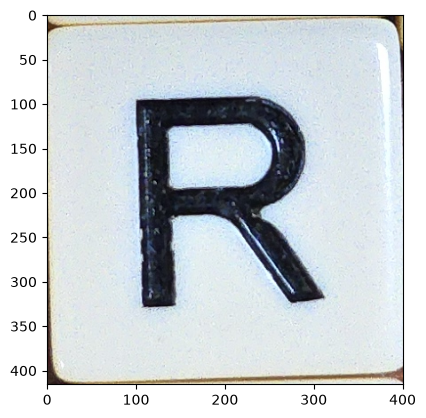

In [ ]:
avgTileLen = findNewAvgTileLen(boxes)
lenMOE = .25
maxLen = avgTileLen * (1+lenMOE)
minLen = avgTileLen * (1-lenMOE)

#Change to numpy masks

conditions = (.9<aspectRatios) & (aspectRatios<1.1) 
boxes = boxes[conditions]
len(boxes)


### Filter For Duplicates

In [137]:
from sklearn.neighbors import NearestNeighbors
neigh = NearestNeighbors(n_neighbors=6, algorithm='ball_tree').fit(centers)
indices = neigh.kneighbors(centers, return_distance=False)

Overlap found - (815,2369) and (813,2371) 
Overlap found - (813,2371) and (815,2369) 


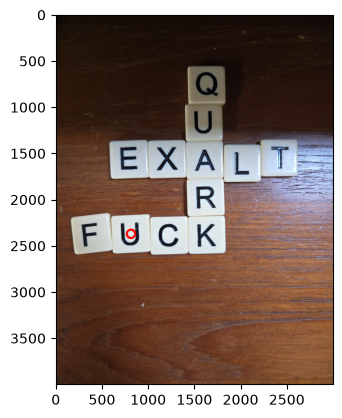

12

In [139]:
avgTileLen = findNewAvgTileLen(boxes)

duplicates=[]
for neighbors in indices:
    mainTile = centers[neighbors[0]]
    for neighbor in neighbors[1:]:
        diffX = mainTile[0] - centers[neighbor][0]
        diffY = mainTile[1] - centers[neighbor][1]
        if ( abs(diffX) < avgTileLen/2 and abs(diffY) < avgTileLen/2 ):
            print(f'Overlap found - ({mainTile[0]},{mainTile[1]}) and ({centers[neighbor][0]},{centers[neighbor][1]}) ')
            if(neighbors[0] not in duplicates):
                duplicates.append(neighbor)

boxes=np.delete(boxes,duplicates,axis=0)
centers = np.delete(centers,duplicates, axis=0)

len(centers)

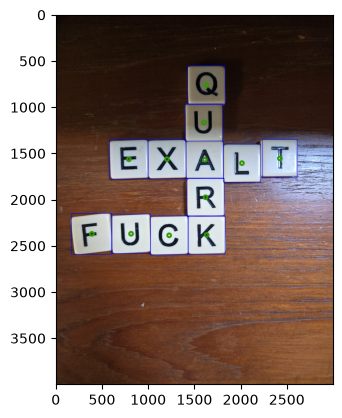

12

In [140]:
drawOn2 = image.copy()

for x1,y1,x2,y2 in boxes:
    xAvg = (x1+x2)//2
    yAvg = (y1+y2)//2
    avgTileLen += x2-x1
    avgTileLen += y2-y1

    cv2.circle(drawOn2, (xAvg,yAvg),20,(50,150,0),20)
    cv2.rectangle(drawOn2, (x1,y1),(x2,y2), (0,0,250),3)

plt.imshow(drawOn2)
plt.show()
len(boxes)

## Crop and export

In [183]:
from cv2.typing import MatLike

def getCropped(image:MatLike, box) -> MatLike:
    x1,y1,x2,y2 = map(int, box)
    croppedImage = image[y1:y2,x1:x2]
    return croppedImage

def exportImage(image:MatLike, fileName, basePath='cnnTraining'):
    fullPath = f'./{basePath}/{fileName}.jpg'
    cv2.imwrite(fullPath,image)

In [ ]:
import os

batch = 'Batch2'
imageDir = 'cnnTraining/_Full_Images'
fullPath = os.path.join(imageDir,batch)
print(fullPath)
count = 0

images = [imageFile for _,_, imageFile in os.walk(fullPath)][0]
print(images)

for imageFilePath in images:
    imageFullPath = os.path.join(fullPath,imageFilePath)
    image = cv2.imread(imageFullPath)
    result = myModel.predict(image)
    boxes = result[0].boxes.xyxy.cpu().numpy()
    for crop in boxes:
        croppedImage = getCropped(image,crop)
        croppedOutPath = os.path.join('cnnTraining',f'{count}.jpg')
        exportImage(croppedImage,str(count))
        count+=1


cnnTraining/_Full_Images\Batch1
['20260819_211004.jpg', '20260819_211006.jpg', '20260819_211031.jpg', '20260819_211035.jpg', '20260819_211058.jpg', '20260819_211105.jpg', '20260819_211108.jpg', '20260819_211120.jpg', '20260819_211121.jpg', '20260819_211208.jpg', '20260819_211209.jpg', '20260819_211218.jpg', '20260819_211221.jpg', '20260819_211224.jpg']

0: 640x640 53 Tiles, 448.3ms
Speed: 6.3ms preprocess, 448.3ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
cnnTraining\0.jpg
cnnTraining\1.jpg
cnnTraining\2.jpg
cnnTraining\3.jpg
cnnTraining\4.jpg
cnnTraining\5.jpg
cnnTraining\6.jpg
cnnTraining\7.jpg
cnnTraining\8.jpg
cnnTraining\9.jpg
cnnTraining\10.jpg
cnnTraining\11.jpg
cnnTraining\12.jpg
cnnTraining\13.jpg
cnnTraining\14.jpg
cnnTraining\15.jpg
cnnTraining\16.jpg
cnnTraining\17.jpg
cnnTraining\18.jpg
cnnTraining\19.jpg
cnnTraining\20.jpg
cnnTraining\21.jpg
cnnTraining\22.jpg
cnnTraining\23.jpg
cnnTraining\24.jpg
cnnTraining\25.jpg
cnnTraining\26.jpg
cnnTraining\27

## Give each box a letter, create `TileInfo` Objects

## Visualize board with BFS using only letters

## Letters --> Words

## Visualize board using words and intersect indices

## Neighbors 1